# 第三次作业：Gymnasium + DQN 实验

## 作业目标

本次作业要求你基于 `CartPole-v1` 环境完成一个 Deep Q-Network（DQN）智能体。代码框架已经给出，其中扣掉了 **5 处关键代码**。你需要补全 5 处 `TODO`，运行训练，并提交训练结果。

本次作业对应课程内容：

- Gymnasium 的 `reset()` / `step()` 交互循环
- CartPole 的观测空间与动作空间
- Q-Learning 到 DQN 的过渡
- 经验回放、目标网络、epsilon-greedy
- PyTorch 网络前向传播、loss 计算与反向传播

参考资料：

- Gymnasium CartPole 文档：https://gymnasium.farama.org/environments/classic_control/cart_pole/
- PyTorch DQN 官方教程：https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

## 实验环境

如果缺少依赖，请先运行：

In [2]:
# 如果当前环境还没有安装依赖，可以取消注释运行：
!pip install "gymnasium[classic-control]" torch matplotlib numpy

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 提交内容

请提交：

1. 补全后的 `DQN_Lab_第三次作业.ipynb`
2. 训练结果图 `dqn_training_results.png`
3. 实验报告：不超过 **4 页 A4**

评分标准：5 处 TODO 每处 20 分。代码能完整运行并生成曲线可加 10 分；测试 20 回合平均 reward 超过 300 可加 10 分。

## TODO 总览

| TODO | 内容 |
|---|---|
| TODO 1 | 定义 DQN 网络结构 |
| TODO 2 | 实现 epsilon-greedy 动作选择 |
| TODO 3 | 计算当前 Q 值 `Q(s,a)` |
| TODO 4 | 计算 TD 目标 `target_q` |
| TODO 5 | 计算 loss 并更新网络参数 |

## 1. 导入库

In [3]:
from collections import deque
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("device:", DEVICE)

device: cpu


## 2. 经验回放缓冲区

DQN 不直接用刚刚产生的一条经验训练，而是把经验存入 replay buffer，再随机采样一个 batch。这样可以降低连续样本之间的相关性。

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

## 3. DQN 网络

输入是 CartPole 的 4 维状态，输出是 2 个动作的 Q 值。

In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()

        # TODO 1:
        # 定义三层全连接网络：
        # state_dim -> hidden_dim -> hidden_dim -> action_dim
        # 两个隐藏层后都使用 ReLU。
        # 请用你的实现替换下面两行占位代码。
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
          )
        #self.net = None
        #raise NotImplementedError("TODO 1: define self.net")

    def forward(self, x):
        return self.net(x)

## 4. DQN Agent

Agent 包含：

- `policy_net`：当前正在训练的 Q 网络
- `target_net`：计算 TD 目标的目标网络
- `ReplayBuffer`：经验回放
- `select_action()`：epsilon-greedy
- `train_step()`：采样 batch 并更新网络

In [6]:
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
        buffer_size=20_000,
        batch_size=64,
        target_update_freq=10,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.update_count = 0

        self.policy_net = DQN(state_dim, action_dim).to(DEVICE)
        self.target_net = DQN(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(buffer_size)

    def select_action(self, state, training=True):
        # TODO 2:
        # 实现 epsilon-greedy：
        # 训练时，以 epsilon 概率随机选动作；
        # 否则用 policy_net 计算 Q 值并选择 argmax 动作。
        # 注意测试时 training=False，应总是选择 argmax。
        # 请用你的实现替换下面一行占位代码。
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()
        #raise NotImplementedError("TODO 2: implement epsilon-greedy")

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)
    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(
            self.batch_size
        )

        states = torch.tensor(states, dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(actions, dtype=torch.long, device=DEVICE)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

        # TODO 3:
        # 用 policy_net(states) 得到所有动作 Q 值，
        # 再用 gather 取出实际执行动作 actions 对应的 Q(s,a)。
        # 请用你的实现替换下面两行占位代码。
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        #current_q = None
        #raise NotImplementedError("TODO 3: compute current_q")

        # TODO 4:
        # 用 target_net(next_states) 计算下一状态最大 Q 值。
        # TD target = rewards + gamma * max_next_q * (1 - dones)
        # 这部分不需要梯度。
        # 请用你的实现替换下面两行占位代码。
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)
        #target_q = None
        #raise NotImplementedError("TODO 4: compute target_q")

        # TODO 5:
        # 计算 MSE loss，清零梯度，反向传播，更新 policy_net 参数。
        # 请用你的实现替换下面两行占位代码。
        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        #loss = None
        #raise NotImplementedError("TODO 5: optimize policy_net")

        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

## 5. 训练函数

In [7]:
def train_dqn(num_episodes=400):
    env = gym.make("CartPole-v1")
    env.action_space.seed(SEED)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    agent = DQNAgent(state_dim, action_dim)

    rewards_history = []
    losses_history = []

    print(f"state_dim={state_dim}, action_dim={action_dim}")

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        episode_reward = 0.0
        episode_losses = []
        done = False

        while not done:
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store_transition(state, action, reward, next_state, done)
            loss = agent.train_step()
            if loss is not None:
                episode_losses.append(loss)

            state = next_state
            episode_reward += reward

        agent.decay_epsilon()
        rewards_history.append(episode_reward)
        losses_history.append(np.mean(episode_losses) if episode_losses else 0.0)

        if (episode + 1) % 20 == 0:
            avg_reward = np.mean(rewards_history[-20:])
            print(
                f"episode={episode + 1:4d} "
                f"reward={episode_reward:6.1f} "
                f"avg20={avg_reward:6.1f} "
                f"epsilon={agent.epsilon:.3f}"
            )

    env.close()
    return agent, rewards_history, losses_history

## 6. 测试与画图

In [8]:
def evaluate(agent, num_episodes=20):
    env = gym.make("CartPole-v1")
    rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=10_000 + episode)
        episode_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

        rewards.append(episode_reward)

    env.close()
    print(f"eval avg reward: {np.mean(rewards):.1f}")
    return rewards


def plot_results(rewards_history, losses_history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(rewards_history, alpha=0.35, label="episode reward")
    if len(rewards_history) >= 20:
        avg = np.convolve(rewards_history, np.ones(20) / 20, mode="valid")
        axes[0].plot(range(19, len(rewards_history)), avg, label="avg20")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].set_title("DQN Reward")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(losses_history, label="loss")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Training Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("dqn_training_results.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. 运行训练

完成 5 处 TODO 后，再运行下面这个单元格。

state_dim=4, action_dim=2
episode=  20 reward=  19.0 avg20=  24.9 epsilon=0.905
episode=  40 reward=  47.0 avg20=  25.5 epsilon=0.818
episode=  60 reward=  65.0 avg20=  54.0 epsilon=0.740
episode=  80 reward=  79.0 avg20=  52.5 epsilon=0.670
episode= 100 reward=  96.0 avg20=  72.2 epsilon=0.606
episode= 120 reward=  23.0 avg20=  91.2 epsilon=0.548
episode= 140 reward=  86.0 avg20= 108.5 epsilon=0.496
episode= 160 reward= 190.0 avg20= 162.9 epsilon=0.448
episode= 180 reward= 263.0 avg20= 198.2 epsilon=0.406
episode= 200 reward= 500.0 avg20= 191.3 epsilon=0.367
episode= 220 reward= 198.0 avg20= 158.1 epsilon=0.332
episode= 240 reward=  87.0 avg20= 187.7 epsilon=0.300
episode= 260 reward=  16.0 avg20= 207.7 epsilon=0.272
episode= 280 reward= 500.0 avg20= 223.8 epsilon=0.246
episode= 300 reward= 199.0 avg20= 300.9 epsilon=0.222
episode= 320 reward= 500.0 avg20= 219.4 epsilon=0.201
episode= 340 reward= 500.0 avg20= 333.9 epsilon=0.182
episode= 360 reward= 197.0 avg20= 241.4 epsilon=0.165
ep

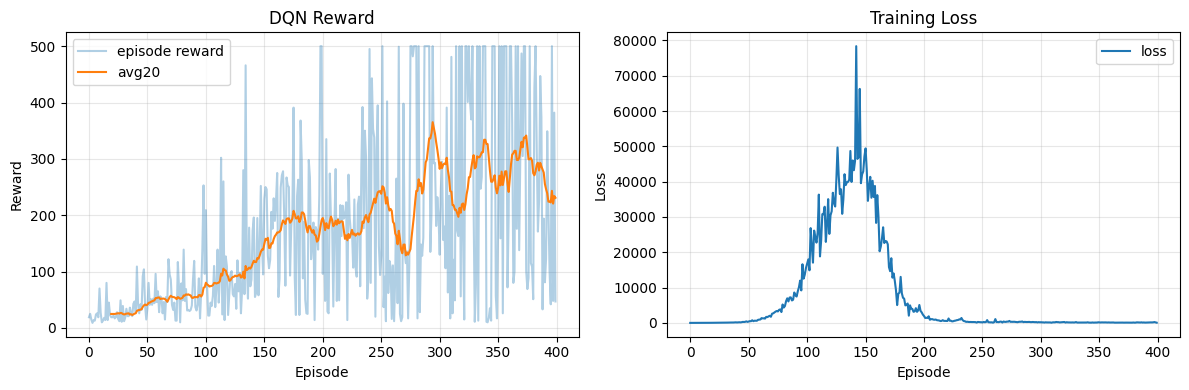

In [9]:
agent, rewards_history, losses_history = train_dqn(num_episodes=400)
test_rewards = evaluate(agent, num_episodes=20)
plot_results(rewards_history, losses_history)